# Bank Marketing - MERGE Pipeline

**Tích hợp toàn bộ AI_EDA.ipynb + eda.ipynb thành 1 pipeline duy nhất.**

---
## MỤC TIÊU
1. Hợp nhất code từ 2 notebook thành 1 pipeline sạch
2. Feature Engineering mới (theo danh sách đã thống nhất)
3. Chạy 3 model: LogisticRegression / XGBoost / LightGBM
4. Đánh giá bằng 5-fold Stratified CV
5. SHAP trên model tốt nhất
6. Error Analysis
7. EDA 2 chiều (interaction)
8. Precision@top30% làm metric phụ
9. Feature nhóm 4: pdays_recent, age_group


---
## 0. IMPORTS & CONFIG

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_score, recall_score,
    confusion_matrix, roc_curve
)
import xgboost as xgb
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Seed
SEED = 42
np.random.seed(SEED)

print('All imports OK.')

All imports OK.


---
## 1. LOAD DATA

In [36]:
df_raw = pd.read_csv('bank+marketing/bank/bank-full.csv', sep=';')
df = df_raw.copy()

# Target binary
df['target'] = (df['y'] == 'yes').astype(int)

print(f'Shape: {df.shape}')
print(f'Target distribution: {df["target"].value_counts().to_dict()}')
print(f'Target rate: {df["target"].mean():.4f}')
df.head()

Shape: (45211, 18)
Target distribution: {0: 39922, 1: 5289}
Target rate: 0.1170


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


---
## 2. DATA AUDIT
### 2.1 Null & Unknown

In [37]:
print('=== NULL VALUES ===')  
print(df.isnull().sum())
print(f'\nTổng null: {df.isnull().sum().sum()}')

=== NULL VALUES ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
target       0
dtype: int64

Tổng null: 0


In [38]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
unknown_info = []
for col in cat_cols:
    count = (df[col] == 'unknown').sum()
    pct = count / len(df) * 100
    unknown_info.append({'Column': col, 'Unknown_Count': count, 'Percentage': round(pct, 2)})

unknown_df = pd.DataFrame(unknown_info)
unknown_df = unknown_df[unknown_df['Unknown_Count'] > 0].sort_values('Unknown_Count', ascending=False)
print('=== UNKNOWN VALUES ===')
print(unknown_df.to_string(index=False))
print()
print('Nhận xét: poutcome 82% unknown = khách mới chưa từng gọi')
print('job=unknown: 0.64%, education=unknown: 4.11% → Giữ như category riêng')

=== UNKNOWN VALUES ===
   Column  Unknown_Count  Percentage
 poutcome          36959       81.75
  contact          13020       28.80
education           1857        4.11
      job            288        0.64

Nhận xét: poutcome 82% unknown = khách mới chưa từng gọi
job=unknown: 0.64%, education=unknown: 4.11% → Giữ như category riêng


In [71]:
pdays_neg1 = (df['pdays'] == -1).sum()
poutcome_unk = (df['poutcome'] == 'unknown').sum()
print(f'pdays == -1:          {pdays_neg1} ({pdays_neg1/len(df)*100:.2f}%)')
print(f'poutcome == unknown:  {poutcome_unk} ({poutcome_unk/len(df)*100:.2f}%)')
print(f'Chenh lech:          {abs(pdays_neg1 - poutcome_unk)} records\n')

# Cross-tab de tim 5 records bat thuong
ct = pd.crosstab(df['pdays'] == -1, df['poutcome'] == 'unknown',
                 rownames=['pdays==-1'], colnames=['poutcome==unknown'])
print('Cross-tab (True=yes, False=no):')
print(ct)

# Nhom B: pdays=-1 nhung poutcome != unknown (ky la)
grp_B = df[(df['pdays'] == -1) & (df['poutcome'] != 'unknown')]
# Nhom C: pdays != -1 nhung poutcome == unknown (ky la)
grp_C = df[(df['pdays'] != -1) & (df['poutcome'] == 'unknown')]

print(f'\nNhóm pdays=-1 nhung poutcome!=unknown: {len(grp_B)} records')
if len(grp_B) > 0: print(grp_B[['pdays', 'poutcome', 'previous']].head())

print(f'Nhom C pdays!=-1 nhung poutcome==unknown: {len(grp_C)} records')
if len(grp_C) > 0: print(grp_C[['pdays', 'poutcome', 'previous']].head())

print("\n=> Gần khớp (lech 5 records = data lệch nhỏ, có thể là vì chưa làm sạch kĩ, ~0.01%)")
print("=> Dùng pdays==-1 làm cơ sở cho is_new_customer (vì không gây lỗi logic), tuy nhiên không bỏ đi vì về cơ bản tỉ lệ 0.01% không gây nhiễu với mô hình cây ")


pdays == -1:          36954 (81.74%)
poutcome == unknown:  36959 (81.75%)
Chenh lech:          5 records

Cross-tab (True=yes, False=no):
poutcome==unknown  False  True 
pdays==-1                      
False               8252      5
True                   0  36954

Nhóm pdays=-1 nhung poutcome!=unknown: 0 records
Nhom C pdays!=-1 nhung poutcome==unknown: 5 records
       pdays poutcome  previous
40658     98  unknown         1
41821    168  unknown         5
42042    188  unknown         2
43978    416  unknown         2
45021    528  unknown         7

=> Gần khớp (lech 5 records = data lệch nhỏ, có thể là vì chưa làm sạch kĩ, ~0.01%)
=> Dùng pdays==-1 làm cơ sở cho is_new_customer (vì không gây lỗi logic), tuy nhiên không bỏ đi vì về cơ bản tỉ lệ 0.01% không gây nhiễu với mô hình cây 


### 2.2 Phân tích unknown job & education

In [40]:
print('=== EDUCATION=unknown phân bố job ===')
edu_unk = df[df['education'] == 'unknown']
print(edu_unk['job'].value_counts())

print('\n=== JOB=unknown phân bố education ===')
job_unk = df[df['job'] == 'unknown']
print(job_unk['education'].value_counts())

both_unk = ((df['education'] == 'unknown') & (df['job'] == 'unknown')).sum()
print(f'\nCả 2 đều unknown: {both_unk}')
print('=> Không có pattern rõ để impute → Giữ unknown là 1 category riêng')

=== EDUCATION=unknown phân bố job ===
job
blue-collar      454
technician       242
management       242
admin.           171
student          163
services         150
unknown          127
retired          119
entrepreneur      76
housemaid         45
self-employed     39
unemployed        29
Name: count, dtype: int64

=== JOB=unknown phân bố education ===
education
unknown      127
secondary     71
primary       51
tertiary      39
Name: count, dtype: int64

Cả 2 đều unknown: 127
=> Không có pattern rõ để impute → Giữ unknown là 1 category riêng


### 2.2.1 Trực quan hóa Job/Education Unknown

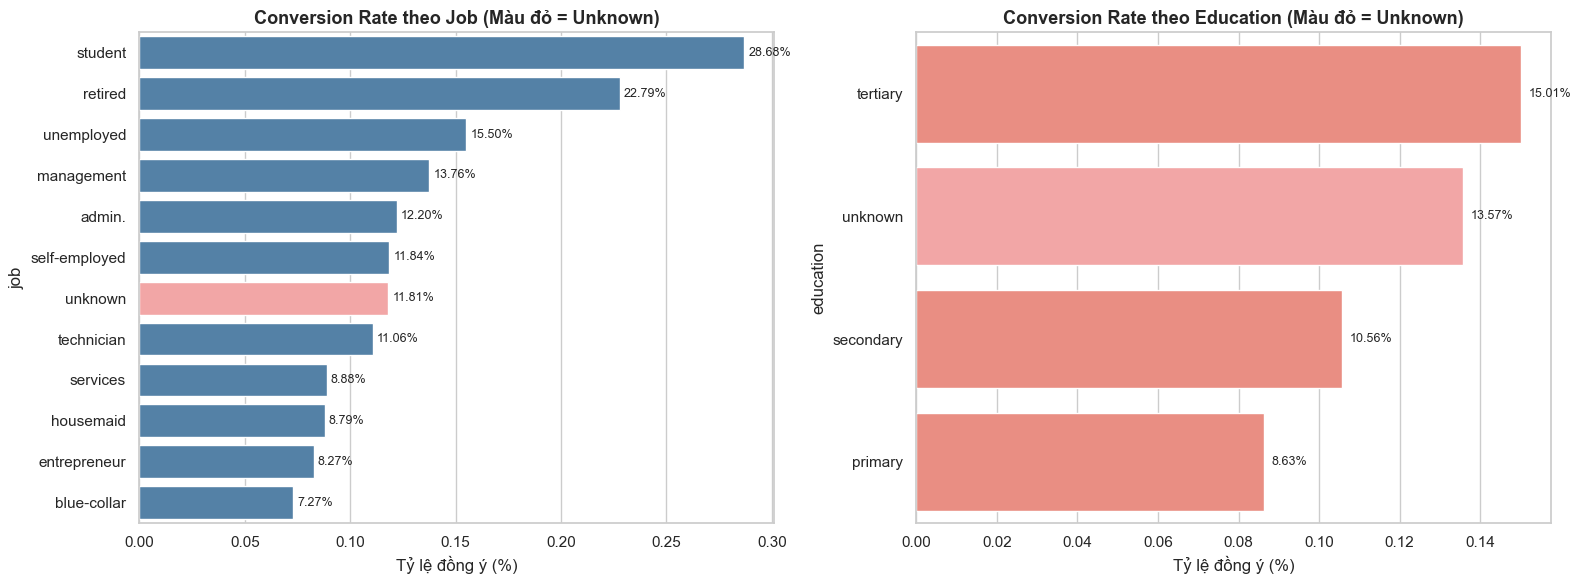

Tỷ lệ đồng ý TRUNG BÌNH toàn bộ: 11.70%
Tỷ lệ đồng ý nhóm Job=unknown:    11.81%
Tỷ lệ đồng ý nhóm Edu=unknown:    13.57%

Nhận xét: Cả nhóm Unknown Job (11.81%) và Unknown Education (13.57%) đều có tỷ lệ đồng ý cao hơn mức trung bình một xíu (11.70%). 
Đây là signal không quá mạnh và KHÔNG QUÁ quan trọng cho thấy 'unknown' mang tín hiệu phân loại tốt


In [154]:
# Visualize Conversion Rates for Job and Education (emphasizing Unknown)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Conversion Rate by Job
job_cr = df.groupby('job')['target'].mean().sort_values(ascending=False)
colors = ['#FF9999' if x == 'unknown' else 'steelblue' for x in job_cr.index]
sns.barplot(x=job_cr.values, y=job_cr.index, ax=axes[0], palette=colors)
axes[0].set_title('Conversion Rate theo Job (Màu đỏ = Unknown)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tỷ lệ đồng ý (%)')
for i, v in enumerate(job_cr.values):
    axes[0].text(v + 0.002, i, f'{v:.2%}', va='center', fontsize=9)

# Subplot 2: Conversion Rate by Education
edu_cr = df.groupby('education')['target'].mean().sort_values(ascending=False)
colors_edu = ['#FF9999' if x == 'unknown' else 'salmon' for x in edu_cr.index]
sns.barplot(x=edu_cr.values, y=edu_cr.index, ax=axes[1], palette=colors_edu)
axes[1].set_title('Conversion Rate theo Education (Màu đỏ = Unknown)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tỷ lệ đồng ý (%)')
for i, v in enumerate(edu_cr.values):
    axes[1].text(v + 0.002, i, f'{v:.2%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Business Insight
avg_cr = df['target'].mean()
unk_job_cr = df[df['job']=='unknown']['target'].mean()
unk_edu_cr = df[df['education']=='unknown']['target'].mean()

print(f'Tỷ lệ đồng ý TRUNG BÌNH toàn bộ: {avg_cr:.2%}')
print(f'Tỷ lệ đồng ý nhóm Job=unknown:    {unk_job_cr:.2%}')
print(f'Tỷ lệ đồng ý nhóm Edu=unknown:    {unk_edu_cr:.2%}')
print(f"\nNhận xét: Cả nhóm Unknown Job ({unk_job_cr:.2%}) và Unknown Education ({unk_edu_cr:.2%}) "
      f"đều có tỷ lệ đồng ý cao hơn mức trung bình một xíu ({avg_cr:.2%}). "
      f"\nĐây là signal không quá mạnh và KHÔNG QUÁ quan trọng cho thấy 'unknown' mang tín hiệu phân loại tốt")

### 2.3 Percentile Analysis - Phát hiện outlier

In [ ]:
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

print('=== BALANCE - Percentile ===')
balance_pct = df['balance'].quantile(percentiles)
for p, v in balance_pct.items():
    print(f'  {int(p*100):>3}%: {v:>10,.0f}')
print(f'  min: {df["balance"].min():>10,.0f}')
print(f'  max: {df["balance"].max():>10,.0f}')
print()
print('QUAN TRỌNG: balance âm KHÔNG phải lỗi - đây là tài khoản nợ!')
print('=> Giữ nguyên giá trị âm, chỉ Winsorize 1% đầu trên')

print('\n=== CAMPAIGN - Percentile ===')
campaign_pct = df['campaign'].quantile(percentiles)
for p, v in campaign_pct.items():
    print(f'  {int(p*100):>3}%: {v:>6,.0f} lần')
print(f'  min: {df["campaign"].min():>6,.0f} lần')
print(f'  max: {df["campaign"].max():>6,.0f} lần')
print('=> 99% = 16 lần, max = 63 lần. Winsorize 1% đầu trên')

=== BALANCE - Percentile ===
    1%:       -627
    5%:       -172
   25%:         72
   50%:        448
   75%:      1,428
   95%:      5,768
   99%:     13,165
  min:     -8,019
  max:    102,127

QUAN TRỌNG: balance âm KHÔNG phải lỗi - đây là tài khoản thấu chi!
=> Giữ nguyên giá trị âm, chỉ Winsorize 1% đầu trên

=== CAMPAIGN - Percentile ===
    1%:      1 lần
    5%:      1 lần
   25%:      1 lần
   50%:      2 lần
   75%:      3 lần
   95%:      8 lần
   99%:     16 lần
  min:      1 lần
  max:     63 lần
=> 99% = 16 lần, max = 63 lần. Winsorize 1% đầu trên


---
## 3. EDA
### 3.1 Phân phối biến liên tục theo target

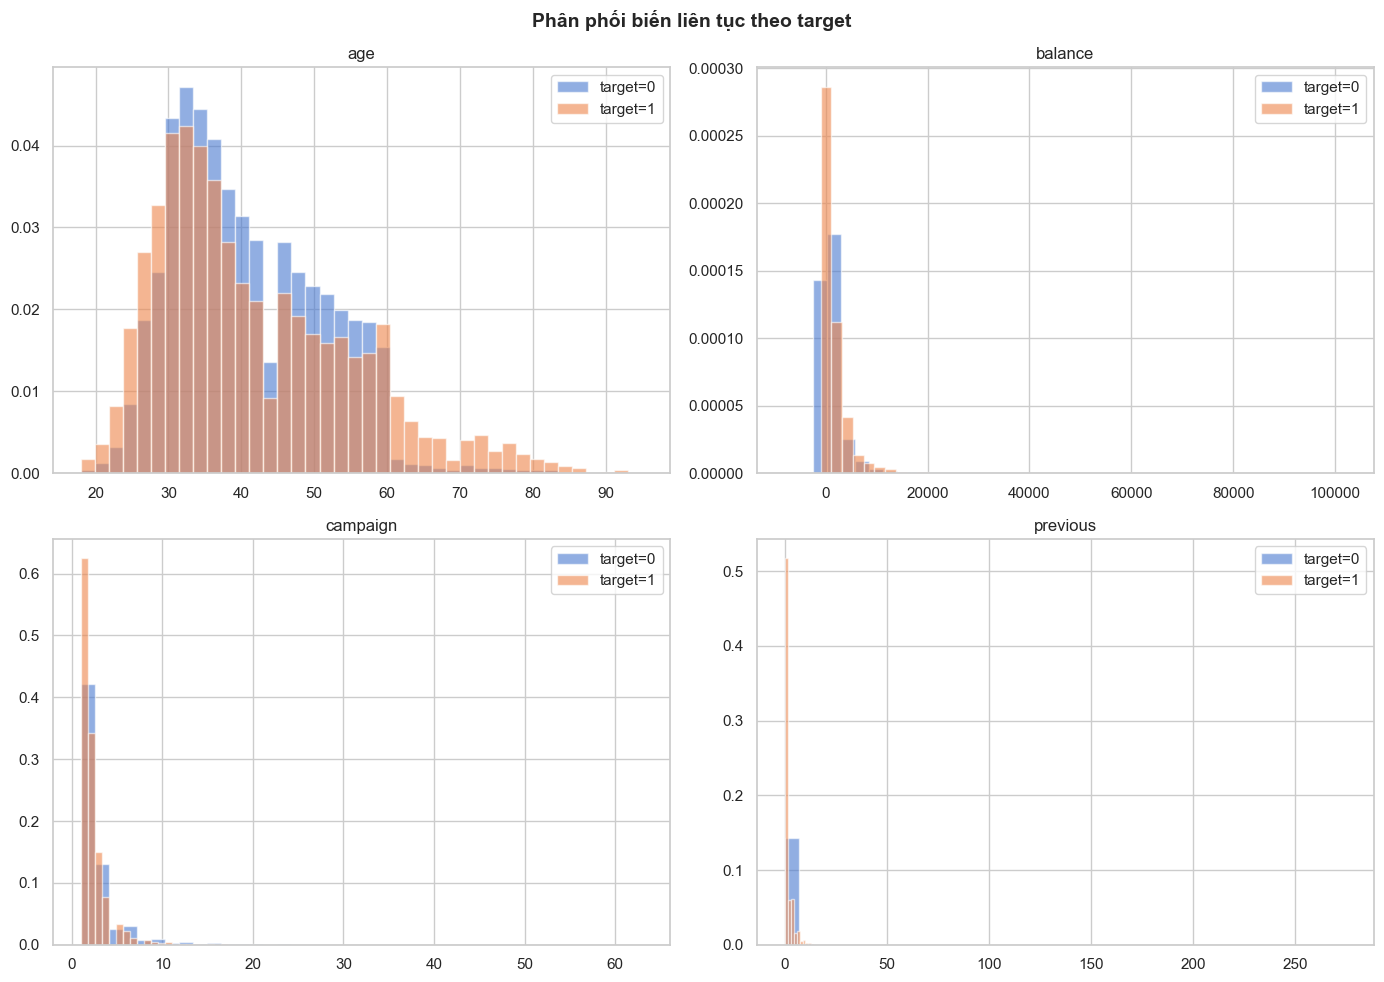

In [42]:
num_cols = ['age', 'balance', 'campaign', 'previous']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, grp in df.groupby('target'):
        axes[i].hist(grp[col], bins=40, alpha=0.6, label=f'target={label}', density=True)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Phân phối biến liên tục theo target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Mann-Whitney U Test (Statistical Significance)

In [150]:
print('=== MANN-WHITNEY U TEST ===')
print(f'{"Feature":<15} {"U-stat":>12} {"p-value":>12} {"Significant":>12}')
print('-' * 55)

yes = df[df['target'] == 1]
no  = df[df['target'] == 0]

for col in ['age', 'balance', 'campaign', 'previous']:
    u_stat, p_val = mannwhitneyu(yes[col], no[col], alternative='two-sided')
    sig = 'YES' if p_val < 0.05 else 'NO'
    print(f'{col:<15} {u_stat:>12.1f} {p_val:>12.4e} {sig:>12}')

print('\n=> Hầu hết p < 0.05, riêng age (p=0.062) không có ý nghĩa thống kê ở mức 5%.')
print('\n=> TUY NHIÊN Ở BIỂU ĐỒ TRÊN TA THẤY TỪ MỨC 60 TUỔI TRỞ LÊN TỈ LỆ MỞ THẺ CAO HƠN HẲN -> CHỈ LÀ K CÓ Ý NGHĨA TRÊN TOÀN BỘ BIẾN')


=== MANN-WHITNEY U TEST ===
Feature               U-stat      p-value  Significant
-------------------------------------------------------
age              103915109.5   6.2818e-02           NO
balance          124589983.5  6.5938e-101          YES
campaign          90300543.5   1.9485e-71          YES
previous         127174833.0  3.4918e-283          YES

=> Hầu hết p < 0.05, riêng age (p=0.062) không có ý nghĩa thống kê ở mức 5%.

=> TUY NHIÊN Ở BIỂU ĐỒ TRÊN TA THẤY TỪ MỨC 60 TUỔI TRỞ LÊN TỈ LỆ MỞ THẺ CAO HƠN HẲN -> CHỈ LÀ K CÓ Ý NGHĨA TRÊN TOÀN BỘ BIẾN


### 3.3 Phân tích biến categorical theo target

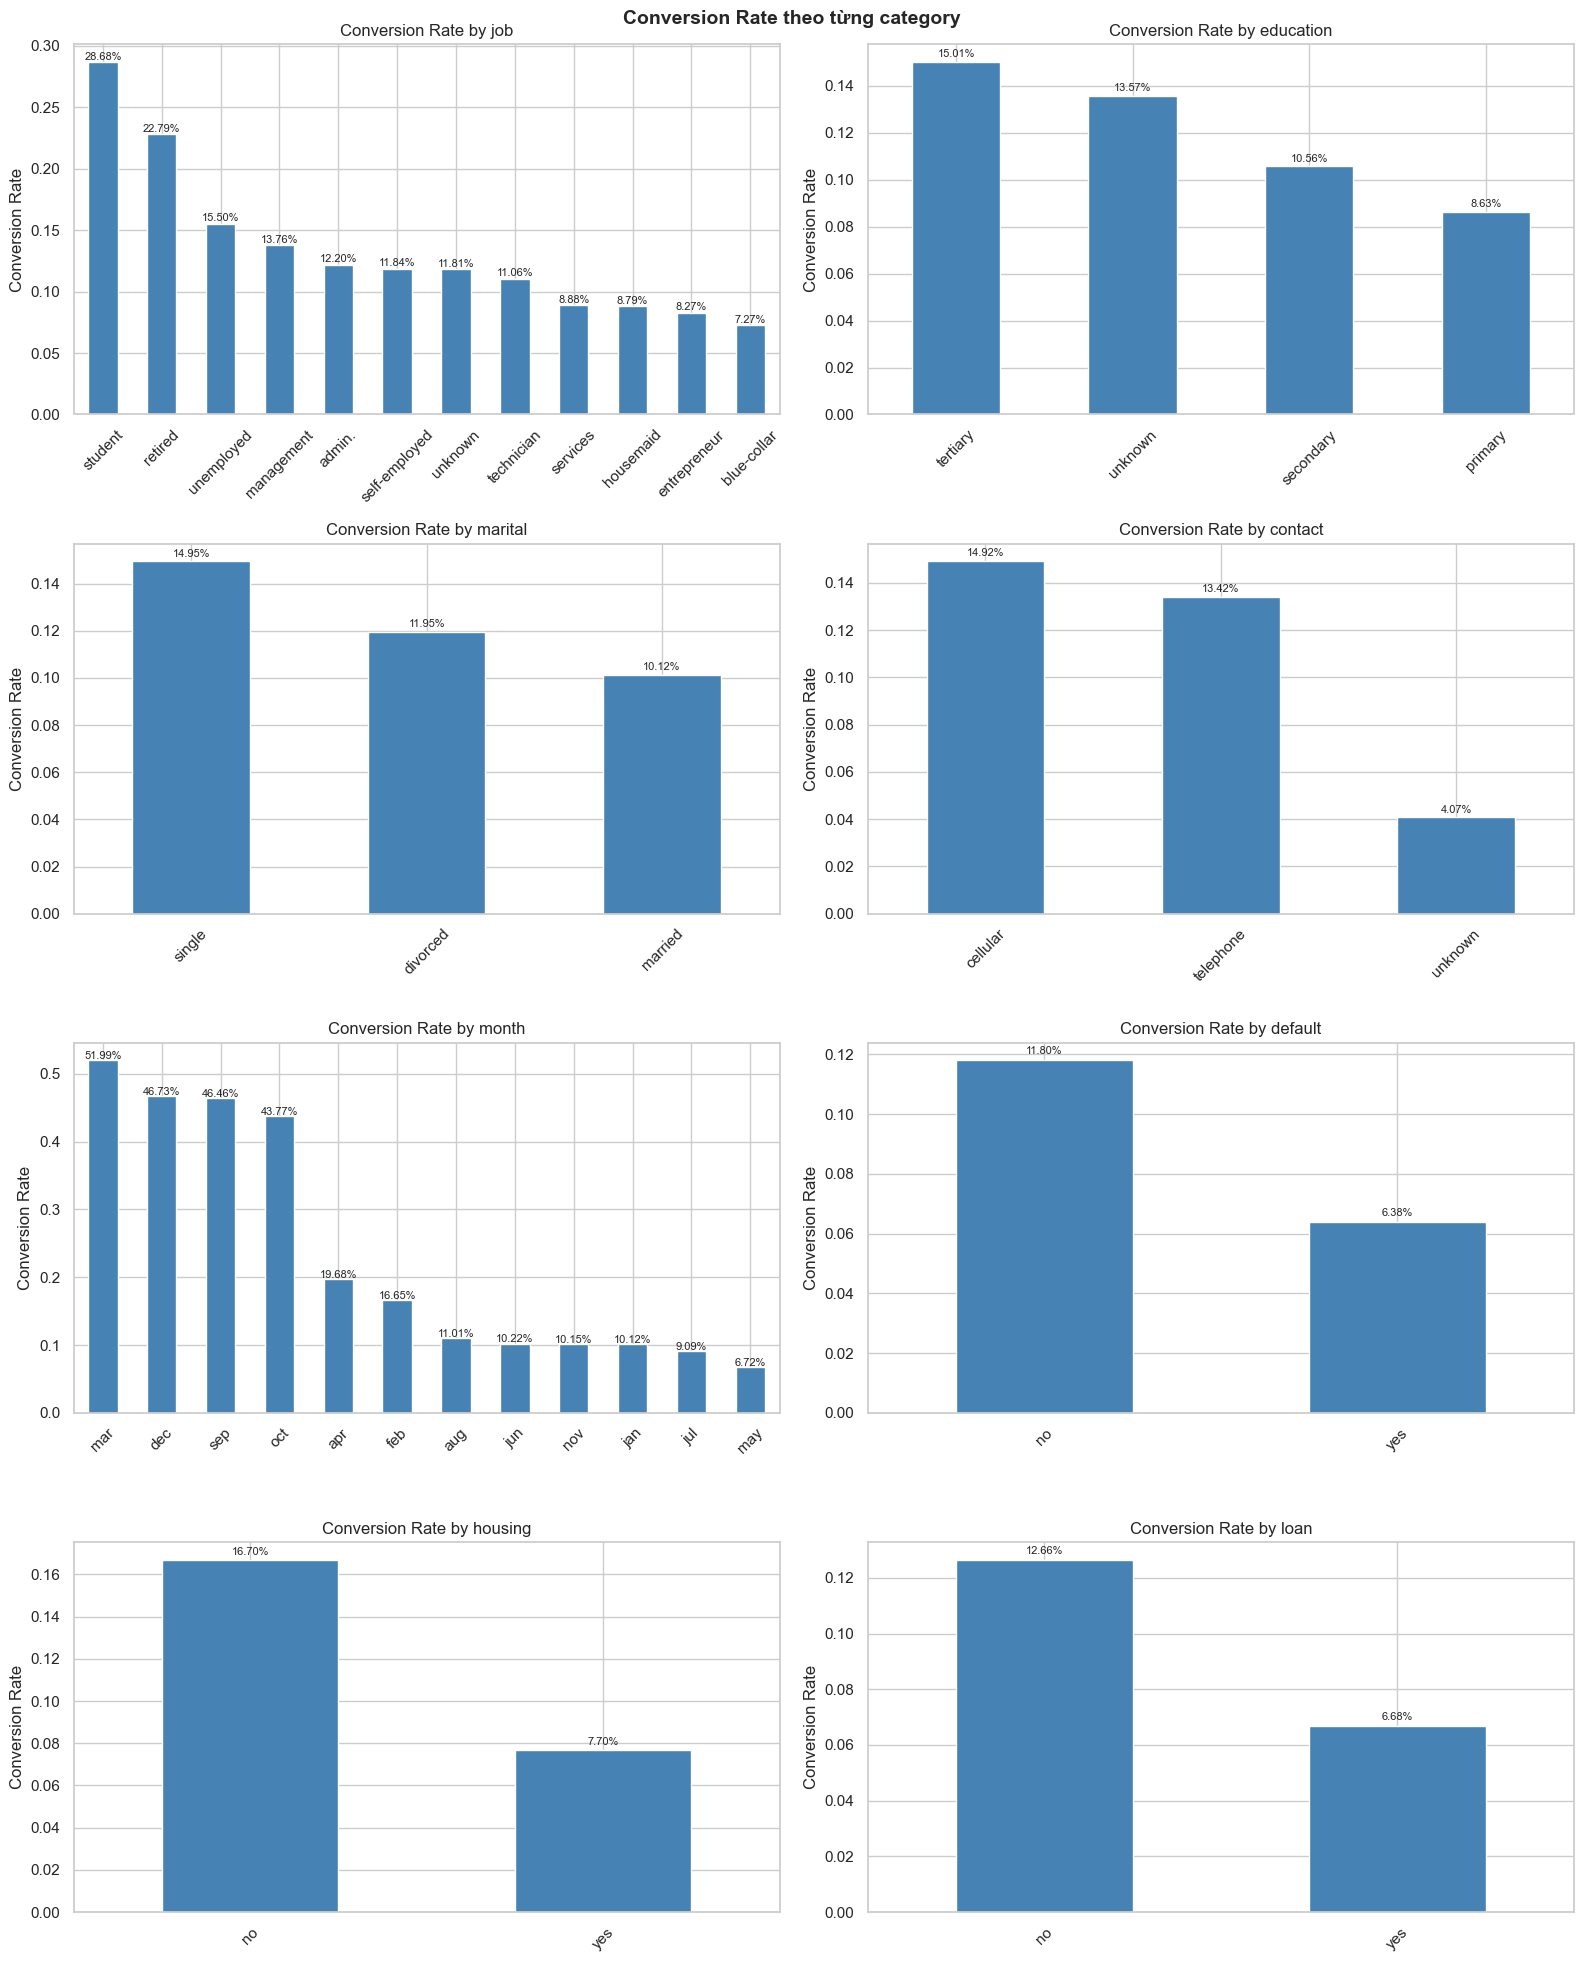

In [44]:
cat_features = ['job', 'education', 'marital', 'contact', 'month', 'default', 'housing', 'loan']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    cr = df.groupby(col)['target'].mean().sort_values(ascending=False)
    cr.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Conversion Rate by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Conversion Rate')
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(cr.values):
        axes[i].text(j, v + 0.002, f'{v:.2%}', ha='center', fontsize=8)

plt.suptitle('Conversion Rate theo từng category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

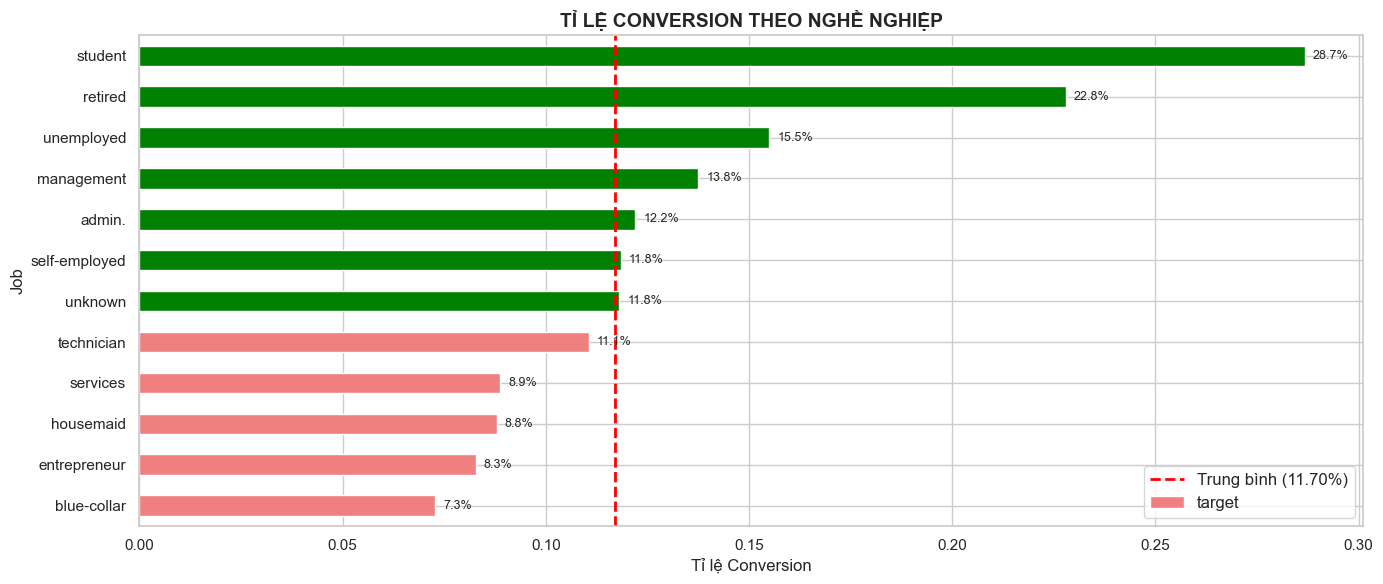


Top 3 nghề convert cao nhất: ['unemployed', 'retired', 'student']
Top 3 nghề convert thấp nhất: ['blue-collar', 'entrepreneur', 'housemaid']


In [156]:
# ============================================================
# Q1: Nghề nào convert cao nhất? (có đường trung bình)
# ============================================================
avg_conv = df['target'].mean()
job_conv = df.groupby('job')['target'].mean().sort_values(ascending=True)

plt.figure(figsize=(14, 6))
colors = ['green' if v > avg_conv else 'lightcoral' for v in job_conv.values]
job_conv.plot(kind='barh', color=colors)
plt.axvline(x=avg_conv, color='red', linestyle='--', linewidth=2, label=f'Trung bình ({avg_conv:.2%})')
plt.title('TỈ LỆ CONVERSION THEO NGHỀ NGHIỆP', fontsize=14, fontweight='bold')
plt.xlabel('Tỉ lệ Conversion')
plt.ylabel('Job')
plt.legend(fontsize=12)

# Thêm % trên mỗi bar
for i, v in enumerate(job_conv.values):
    plt.text(v + 0.002, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nTop 3 nghề convert cao nhất: {list(job_conv.tail(3).index)}')
print(f'Top 3 nghề convert thấp nhất: {list(job_conv.head(3).index)}')

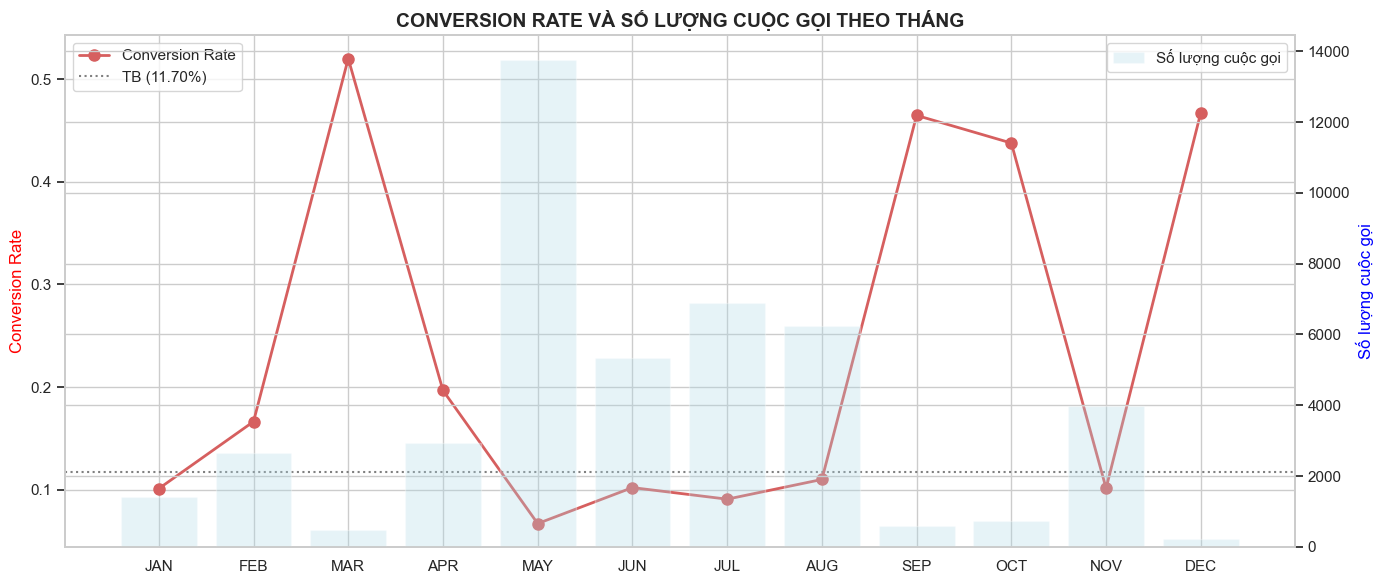

In [157]:
# ============================================================
# Q3: Tháng nào hiệu quả nhất?
# ============================================================
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_conv = df.groupby('month')['target'].agg(['mean', 'count']).reindex(month_order)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar = số lượng campaign
ax2 = ax1.twinx()
ax2.bar(range(len(month_order)), month_conv['count'], alpha=0.3, color='lightblue', label='Số lượng cuộc gọi')
ax2.set_ylabel('Số lượng cuộc gọi', color='blue')

# Line = conversion rate
ax1.plot(range(len(month_order)), month_conv['mean'], 'ro-', linewidth=2, markersize=8, label='Conversion Rate', zorder=5)
ax1.axhline(y=avg_conv, color='gray', linestyle=':', label=f'TB ({avg_conv:.2%})')
ax1.set_ylabel('Conversion Rate', color='red')
ax1.set_xticks(range(len(month_order)))
ax1.set_xticklabels([m.upper() for m in month_order])

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('CONVERSION RATE VÀ SỐ LƯỢNG CUỘC GỌI THEO THÁNG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Deep-Dive: Phân tích Hiệu quả Thực tế và Sai số (Statistical Reliability)

In [ ]:
import scipy.stats as stats

# 1. Tính toán Khoảng tin cậy (Confidence Interval) 95%
def calculate_ci(success, total):
    if total == 0: return (0, 0)
    # Wilson score interval
    z = 1.96 
    p_hat = success / total
    denom = 1 + z**2/total
    adj_p = p_hat + z**2/(2*total)
    err = z * np.sqrt(p_hat*(1-p_hat)/total + z**2/(4*total**2))
    return ( (adj_p - err)/denom, (adj_p + err)/denom )

month_stats = df.groupby('month')['target'].agg(['count', 'mean', 'sum']).reindex(month_order)
cis = [calculate_ci(s, c) for s, c in zip(month_stats['sum'], month_stats['count'])]
month_stats['ci_lower'] = [c[0] for c in cis]
month_stats['ci_upper'] = [c[1] for c in cis]
month_stats['err_y'] = month_stats['mean'] - month_stats['ci_lower']

# 2. Visualize: Total Success vs Conversion Rate with CI
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plot 1: Total Successes (Số lượng tuyệt đối)
sns.barplot(x=month_stats.index, y=month_stats['sum'], ax=ax1, palette='Blues_d')
ax1.set_title('TỔNG SỐ KHÁCH HÀNG ĐỒNG Ý THEO THÁNG (VOLUME)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Số lượng thành công (Successes)')
for i, v in enumerate(month_stats['sum']):
    ax1.text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: CR with 95% Confidence Interval
ax3.errorbar(range(len(month_order)), month_stats['mean'], 
             yerr=month_stats['err_y'], fmt='ro-', capsize=5, linewidth=2, label='Conversion Rate (w/ 95% CI)')
ax3.axhline(y=df['target'].mean(), color='gray', linestyle=':', label='TB Toàn bộ')
ax3.set_title('CONVERSION RATE VỚI KHOẢNG TIN CẬY 95% (STATISTICAL RELIABILITY)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Conversion Rate')
ax3.set_xticks(range(len(month_order)))
ax3.set_xticklabels([m.upper() for m in month_order])
ax3.legend()

plt.tight_layout()
plt.show()

# 3. Phân tích phân khúc: Tìm nguyên nhân
print('=== PHÂN TÍCH CHẤT LƯỢNG LEAD THEO THÁNG ===')
high_cr_months = ['mar', 'sep', 'oct', 'dec']
for m in high_cr_months:
    m_df = df[df['month'] == m]
    prev_success_rate = (m_df['poutcome'] == 'success').mean()
    returning_rate = (m_df['pdays'] != -1).mean()
    print(f'Tháng {m.upper():<3}: Khách cũ: {returning_rate:.1%}, Đã từng Success: {prev_success_rate:.1%}')

may_df = df[df['month'] == 'may']
print(f"Tháng MAY: Khách cũ: {(may_df['pdays'] != -1).mean():.1%}, Đã từng Success: {(may_df['poutcome'] == 'success').mean():.1%}")

#### NHẬN XÉT CHIẾN THUẬT KINH DOANH:
1. **Tháng MAY (tháng 5) là "Tháng Tổng lực":** Mặc dù tỷ lệ đồng ý thấp nhất, nhưng đây là tháng mang về **nhiều khách nhất (925 người)**. Nguyên nhân là do ngân hàng gọi lượng cực lớn (13k cuộc) chủ yếu cho khách hàng mới (96% là khách mới).
2. **Tháng lẻ (Mar, Sep, Oct, Dec) là "Tháng Mục tiêu":** Các tháng này có số cuộc gọi ít nhưng tỷ lệ thành công cao đột biến. Phân tích cho thấy ngân hàng tập trung gọi cho **khách hàng cũ (tỉ lệ 20-30%)** và những người **đã từng đồng ý (success)** ở chiến dịch trước. 
3. **Kết luận:** Tháng hiệu quả nhất về mặt **doanh số (Success Count)** là tháng 5. Tháng hiệu quả nhất về mặt **năng suất (Conversion Rate)** là các tháng transition giữa các quý.

TẠI SAO LẠI CÓ NHỮNG THÁNG MÀ SỐ LẦN GỌI THẤP MÀ TỈ LỆ CAO? CÓ PHẢI DO CÔNG TY NHỮNG THÁNG ĐÓ GẶP VẤN ĐỀ GÌ-> CẦN XÉT SỐ LƯỢNG 

### 3.4 Campaign - Nonlinear Threshold Effect

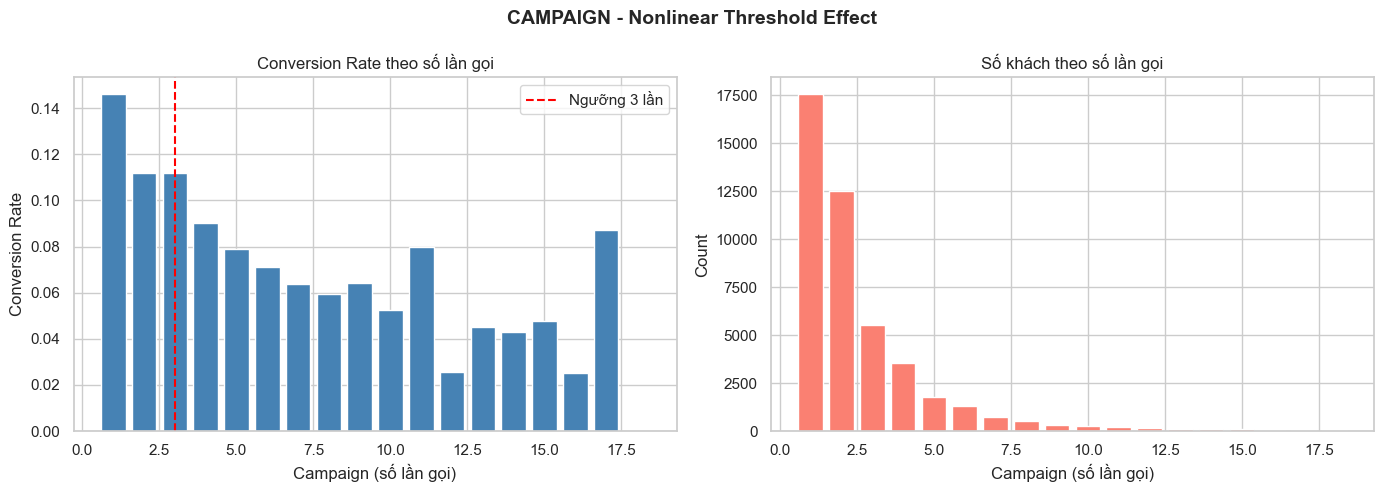

Conversion rate theo bucket:
  1 lần:   0.146
  2-3 lần: 0.112
  4-6 lần: 0.083
  7+ lần:  0.053

>>> 9,641 khách (21.3%) đã bị gọi >3 lần (lãng phí)


In [45]:
# Conversion rate theo số lần gọi (campaign)
campaign_cr = df.groupby('campaign')['target'].agg(['mean', 'count'])
campaign_cr.columns = ['conversion_rate', 'count']
campaign_cr = campaign_cr[campaign_cr['count'] >= 50]  # chỉ lấy nhóm có >= 50 mẫu

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot conversion rate
axes[0].bar(campaign_cr.index, campaign_cr['conversion_rate'], color='steelblue')
axes[0].axvline(x=3, color='red', linestyle='--', label='Ngưỡng 3 lần')
axes[0].set_title('Conversion Rate theo số lần gọi')
axes[0].set_xlabel('Campaign (số lần gọi)')
axes[0].set_ylabel('Conversion Rate')
axes[0].legend()

# Plot count
axes[1].bar(campaign_cr.index, campaign_cr['count'], color='salmon')
axes[1].set_title('Số khách theo số lần gọi')
axes[1].set_xlabel('Campaign (số lần gọi)') 
axes[1].set_ylabel('Count')

plt.suptitle('CAMPAIGN - Nonlinear Threshold Effect', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Conversion rate theo bucket:')
print(f'  1 lần:   {df[df["campaign"]==1]["target"].mean():.3f}')
print(f'  2-3 lần: {df[df["campaign"].between(2,3)]["target"].mean():.3f}')
print(f'  4-6 lần: {df[df["campaign"].between(4,6)]["target"].mean():.3f}')
print(f'  7+ lần:  {df[df["campaign"]>=7]["target"].mean():.3f}')

# Thông tin quan trọng cho Business
n_over3 = (df['campaign'] > 3).sum()
print(f'\n>>> {n_over3:,} khách ({n_over3/len(df)*100:.1f}%) đã bị gọi >3 lần (lãng phí)')

### 3.5 EDA Interaction - Phân tích 2 chiều (Task 10)

In [46]:
# Double loan analysis
df['has_double_loan_tmp'] = ((df['housing'] == 'yes') & (df['loan'] == 'yes')).astype(int)

loan_groups = [
    ('Không vay', (df['housing'] == 'no') & (df['loan'] == 'no')),
    ('Chỉ vay nhà', (df['housing'] == 'yes') & (df['loan'] == 'no')),
    ('Chỉ vay cá nhân', (df['housing'] == 'no') & (df['loan'] == 'yes')),
    ('Vay cả 2 (double loan)', (df['housing'] == 'yes') & (df['loan'] == 'yes')),
]

print('=== DOUBLE LOAN ANALYSIS ===')
for name, mask in loan_groups:
    count = mask.sum()
    cr = df[mask]['target'].mean()
    print(f'{name:30s}: {count:>6,} ({count/len(df)*100:.1f}%)  |  Conv Rate: {cr:.3f}')

double_loan_cr = df[df['has_double_loan_tmp'] == 1]['target'].mean()
no_loan_cr = df[(df['housing'] == 'no') & (df['loan'] == 'no')]['target'].mean()
print(f'\n=> Double loan vs Không vay: {double_loan_cr:.3f} vs {no_loan_cr:.3f}')

df.drop(columns=['has_double_loan_tmp'], inplace=True)

=== DOUBLE LOAN ANALYSIS ===
Không vay                     : 17,204 (38.1%)  |  Conv Rate: 0.182
Chỉ vay nhà                   : 20,763 (45.9%)  |  Conv Rate: 0.080
Chỉ vay cá nhân               :  2,877 (6.4%)  |  Conv Rate: 0.076
Vay cả 2 (double loan)        :  4,367 (9.7%)  |  Conv Rate: 0.061

=> Double loan vs Không vay: 0.061 vs 0.182


In [47]:
# Prev success analysis
prev_success_mask = df['poutcome'] == 'success'
prev_success_cr = df[prev_success_mask]['target'].mean()
prev_success_count = prev_success_mask.sum()

new_customer_mask = df['pdays'] == -1
returning_mask = ~new_customer_mask

print('=== PREV SUCCESS ANALYSIS ===')
print(f'Khách mới (pdays=-1):           {new_customer_mask.sum():>6,} ({new_customer_mask.sum()/len(df)*100:.1f}%)  | Conv: {df[new_customer_mask]["target"].mean():.3f}')
print(f'Khách cũ (có lịch sử):          {returning_mask.sum():>6,} ({returning_mask.sum()/len(df)*100:.1f}%)  | Conv: {df[returning_mask]["target"].mean():.3f}')
print(f'  - Trước đó SUCCESS:           {prev_success_count:>6,}   Conv: {prev_success_cr:.3f}')
print(f'  - Trước đó KHÔNG SUCCESS:     {(returning_mask & ~prev_success_mask).sum():>6,}   Conv: {df[returning_mask & ~prev_success_mask]["target"].mean():.3f}')
print(f'\n=> Khách cũ đã đồng ý lần trước: Conv Rate ~{prev_success_cr:.1%} (xác nhận pattern)')

=== PREV SUCCESS ANALYSIS ===
Khách mới (pdays=-1):           36,954 (81.7%)  | Conv: 0.092
Khách cũ (có lịch sử):           8,257 (18.3%)  | Conv: 0.231
  - Trước đó SUCCESS:            1,511   Conv: 0.647
  - Trước đó KHÔNG SUCCESS:      6,746   Conv: 0.137

=> Khách cũ đã đồng ý lần trước: Conv Rate ~64.7% (xác nhận pattern)


In [48]:
# Balance âm vs dương
neg_bal_mask = df['balance'] < 0
zero_bal_mask = df['balance'] == 0
pos_bal_mask = df['balance'] > 0

print('=== BALANCE NEGATIVE ANALYSIS ===')
print(f'Balance < 0 (thấu chi):  {neg_bal_mask.sum():>6,} ({neg_bal_mask.sum()/len(df)*100:.1f}%)  | Conv: {df[neg_bal_mask]["target"].mean():.3f}')
print(f'Balance = 0:             {zero_bal_mask.sum():>6,} ({zero_bal_mask.sum()/len(df)*100:.1f}%)  | Conv: {df[zero_bal_mask]["target"].mean():.3f}')
print(f'Balance > 0:             {pos_bal_mask.sum():>6,} ({pos_bal_mask.sum()/len(df)*100:.1f}%)  | Conv: {df[pos_bal_mask]["target"].mean():.3f}')
print('\n=> Balance âm (thấu chi) có signal khác - feature is_negative_balance = quan trọng')

=== BALANCE NEGATIVE ANALYSIS ===
Balance < 0 (thấu chi):   3,766 (8.3%)  | Conv: 0.056
Balance = 0:              3,514 (7.8%)  | Conv: 0.083
Balance > 0:             37,931 (83.9%)  | Conv: 0.126

=> Balance âm (thấu chi) có signal khác - feature is_negative_balance = quan trọng


---
## 4. FEATURE ENGINEERING

Theo danh sách đã thống nhất:
- **Nhóm 1**: Feature gốc giữ lại (age, balance, campaign, previous, job, marital, education, default, housing, loan, contact, month)
- **Nhóm 2**: Feature gốc bỏ đi (duration, day, pdays gốc, poutcome gốc)
- **Nhóm 3**: Feature engineering mới
- **Nhóm 4**: Feature cân nhắc (pdays_recent, age_group)

### 4.1 Xử lý outlier

In [49]:
df_fe = df.copy()

balance_before = (df_fe['balance'].min(), df_fe['balance'].max())
campaign_before_max = df_fe['campaign'].max()

# Balance: KHÔNG clip âm về 0 (business logic quan trọng!)
# Chỉ Winsorize 1% đầu dưới và 1% đầu trên để loại outlier cực đoan
df_fe['balance'] = winsorize(df_fe['balance'], limits=[0.01, 0.01])

# Campaign: Winsorize 1% đầu trên
df_fe['campaign'] = winsorize(df_fe['campaign'], limits=[0, 0.01])

print('=== KẾT QUẢ XỬ LÝ OUTLIER ===')
print(f'Balance: [{balance_before[0]:,.0f}, {balance_before[1]:,.0f}] => [{df_fe["balance"].min():,.0f}, {df_fe["balance"].max():,.0f}]')
print(f'Campaign: [max={campaign_before_max}] => [max={df_fe["campaign"].max()}]')
print('=> Balance âm được GIỮ LẠI (không clip về 0)! Đây là thông tin thấu chi quan trọng.')

=== KẾT QUẢ XỬ LÝ OUTLIER ===
Balance: [-8,019, 102,127] => [-627, 13,165]
Campaign: [max=63] => [max=16]
=> Balance âm được GIỮ LẠI (không clip về 0)! Đây là thông tin thấu chi quan trọng.


### 4.2 Tạo Feature Mới (Nhóm 3 + Nhóm 4)

In [50]:
# ============================================================
# NHÓM 3 - Feature Engineering (đã thống nhất)
# ============================================================

# is_new_customer: pdays == -1 → khách mới
df_fe['is_new_customer'] = (df_fe['pdays'] == -1).astype(int)

# prev_success: khách cũ đã đồng ý lần trước
df_fe['prev_success'] = (df_fe['poutcome'] == 'success').astype(int)

# contact_known: contact != unknown
df_fe['contact_known'] = (df_fe['contact'] != 'unknown').astype(int)

# is_negative_balance: FEATURE MỚI - balance < 0
df_fe['is_negative_balance'] = (df_fe['balance'] < 0).astype(int)

# campaign_high: FEATURE MỚI - gọi > 3 lần (nonlinear threshold)
df_fe['campaign_high'] = (df_fe['campaign'] > 3).astype(int)

# has_double_loan: FEATURE MỚI - có cả 2 khoản vay
df_fe['has_double_loan'] = ((df_fe['housing'] == 'yes') & (df_fe['loan'] == 'yes')).astype(int)

# campaign_bucket: Nonlinear encoding (thay vì giá trị thô)
def campaign_bucket(x):
    if x == 1:  return '1_lan'
    elif x <= 3: return '2_3_lan'
    elif x <= 6: return '4_6_lan'
    else:        return '7_plus_lan'

df_fe['campaign_bucket'] = df_fe['campaign'].apply(campaign_bucket)

print('=== NHÓM 3 FEATURES ===')
for f in ['is_new_customer', 'prev_success', 'contact_known', 'is_negative_balance', 'campaign_high', 'has_double_loan']:
    cr = df_fe.groupby(f)['target'].mean()
    count = df_fe[f].value_counts()
    print(f'{f}: {count.to_dict()} | Conv: {cr.to_dict()}')

=== NHÓM 3 FEATURES ===
is_new_customer: {1: 36954, 0: 8257} | Conv: {0: 0.2307133341407291, 1: 0.09157330735509012}
prev_success: {0: 43700, 1: 1511} | Conv: {0: 0.09864988558352403, 1: 0.6472534745201853}
contact_known: {1: 32191, 0: 13020} | Conv: {0: 0.040706605222734255, 1: 0.14783635177534094}
is_negative_balance: {0: 41445, 1: 3766} | Conv: {0: 0.12254795512124503, 1: 0.055762081784386616}
campaign_high: {0: 35570, 1: 9641} | Conv: {0: 0.12876019117233622, 1: 0.0735400892023649}
has_double_loan: {0: 40844, 1: 4367} | Conv: {0: 0.12300460287924787, 1: 0.06068239065720174}


In [51]:
# ============================================================
# NHÓM 4 - Feature cân nhắc
# ============================================================

# pdays_recent: khách cũ được gọi gần đây (< 90 ngày)
df_fe['pdays_recent'] = ((df_fe['pdays'] != -1) & (df_fe['pdays'] < 90)).astype(int)

# age_group: binning tuổi thành 4 nhóm
def age_group(age):
    if age < 30:   return 'young'
    elif age < 50: return 'adult'
    elif age < 60: return 'senior'
    else:          return 'retired'

df_fe['age_group'] = df_fe['age'].apply(age_group)

print('=== NHÓM 4 FEATURES ===')
print('pdays_recent:')  
cr = df_fe.groupby('pdays_recent')['target'].mean()
count = df_fe['pdays_recent'].value_counts()
print(f'  Count: {count.to_dict()} | Conv: {cr.to_dict()}')

print('\nage_group:')
age_cr = df_fe.groupby('age_group')['target'].agg(['mean', 'count'])
print(age_cr.round(3))

=== NHÓM 4 FEATURES ===
pdays_recent:
  Count: {0: 44547, 1: 664} | Conv: {0: 0.11378992973713156, 1: 0.3313253012048193}

age_group:
            mean  count
age_group              
adult      0.100  29744
retired    0.336   1784
senior     0.093   8410
young      0.176   5273


### 4.3 Encoding & Feature Selection

In [52]:
# Nhóm 2: Bỏ features
DROP_COLS = ['duration', 'day', 'pdays', 'poutcome', 'y', 'target']

# Categorical features cần one-hot encode
CAT_COLS = ['job', 'marital', 'education', 'contact', 'month', 'campaign_bucket', 'age_group']

# Binary features (đã có dạng 0/1)
BIN_COLS = ['default', 'housing', 'loan',
            'is_new_customer', 'prev_success', 'contact_known',
            'is_negative_balance', 'campaign_high', 'has_double_loan',
            'pdays_recent']

# Convert binary string cols
for col in ['default', 'housing', 'loan']:
    df_fe[col] = (df_fe[col] == 'yes').astype(int)

# Cột numeric giữ nguyên
NUM_COLS = ['age', 'balance', 'campaign', 'previous']

# Target
y = df_fe['target']

# One-hot encode categorical (drop_first=True để tránh đa cộng tuyến)
df_encoded = pd.get_dummies(df_fe.drop(columns=DROP_COLS), 
                            columns=CAT_COLS, 
                            drop_first=True)

X = df_encoded

print(f'Feature set: {X.shape[1]} features')
print(f'Sample: {X.shape[0]} rows')
print('\nSample features:')
print(list(X.columns[:20]))

Feature set: 49 features
Sample: 45211 rows

Sample features:
['age', 'default', 'balance', 'housing', 'loan', 'campaign', 'previous', 'is_new_customer', 'prev_success', 'contact_known', 'is_negative_balance', 'campaign_high', 'has_double_loan', 'pdays_recent', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed']


---
## 5. TRAIN/TEST SPLIT

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target rate: {y_train.mean():.4f}')
print(f'Test target rate: {y_test.mean():.4f}')

# Scale for LogReg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train: (36168, 49), Test: (9043, 49)
Train target rate: 0.1170
Test target rate: 0.1170


---
## 6. 5-FOLD STRATIFIED CROSS-VALIDATION

### 6.1 Logistic Regression

In [54]:
from sklearn.model_selection import cross_validate, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)

scoring = {'auc': 'roc_auc', 'acc': 'accuracy', 'prec': 'precision', 'rec': 'recall'}
lr_cv_results = cross_validate(logreg, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
lr_cv_scores = lr_cv_results['test_auc']

y_pred_lr = cross_val_predict(logreg, X_train_scaled, y_train, cv=cv, n_jobs=-1)
lr_cm = confusion_matrix(y_train, y_pred_lr) / cv.n_splits

print('=== LOGISTIC REGRESSION - 5-fold CV ===')
print(f"AUC:       {lr_cv_results['test_auc'].mean():.4f} ± {lr_cv_results['test_auc'].std():.4f}")
print(f"Accuracy:  {lr_cv_results['test_acc'].mean():.4f} ± {lr_cv_results['test_acc'].std():.4f}")
print(f"Precision: {lr_cv_results['test_prec'].mean():.4f} ± {lr_cv_results['test_prec'].std():.4f}")
print(f"Recall:    {lr_cv_results['test_rec'].mean():.4f} ± {lr_cv_results['test_rec'].std():.4f}")
print('\nConfusion Matrix Trung bình mỗi fold:')
print(lr_cm)

=== LOGISTIC REGRESSION - 5-fold CV AUC ===
Scores: [0.7728 0.7748 0.7626 0.7741 0.7643]
Mean: 0.7697 | Std: 0.0052


### 6.2 XGBoost (với cấu hình đã thống nhất)

In [55]:
# Tỉ lệ yes:no = 39922:5289 ~ 7.5
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.2f}\n')

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,  # Fix quan trọng nhất!
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=300,
    learning_rate=0.05,
    random_state=SEED,
    eval_metric='auc',
    verbosity=0
)

scoring = {'auc': 'roc_auc', 'acc': 'accuracy', 'prec': 'precision', 'rec': 'recall'}
xgb_cv_results = cross_validate(xgb_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
xgb_cv_scores = xgb_cv_results['test_auc']

y_pred_xgb = cross_val_predict(xgb_model, X_train, y_train, cv=cv, n_jobs=-1)
xgb_cm = confusion_matrix(y_train, y_pred_xgb) / cv.n_splits

print('=== XGBOOST - 5-fold CV ===')
print(f"AUC:       {xgb_cv_results['test_auc'].mean():.4f} ± {xgb_cv_results['test_auc'].std():.4f}")
print(f"Accuracy:  {xgb_cv_results['test_acc'].mean():.4f} ± {xgb_cv_results['test_acc'].std():.4f}")
print(f"Precision: {xgb_cv_results['test_prec'].mean():.4f} ± {xgb_cv_results['test_prec'].std():.4f}")
print(f"Recall:    {xgb_cv_results['test_rec'].mean():.4f} ± {xgb_cv_results['test_rec'].std():.4f}")
print('\nConfusion Matrix Trung bình mỗi fold:')
print(xgb_cm)

scale_pos_weight = 7.55
=== XGBOOST - 5-fold CV AUC ===
Scores: [0.7751 0.7836 0.7743 0.7792 0.7753]
Mean: 0.7775 | Std: 0.0035


### 6.3 LightGBM (backup)

In [56]:
lgb_model = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=-1
)

scoring = {'auc': 'roc_auc', 'acc': 'accuracy', 'prec': 'precision', 'rec': 'recall'}
lgb_cv_results = cross_validate(lgb_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
lgb_cv_scores = lgb_cv_results['test_auc']

y_pred_lgb = cross_val_predict(lgb_model, X_train, y_train, cv=cv, n_jobs=-1)
lgb_cm = confusion_matrix(y_train, y_pred_lgb) / cv.n_splits

print('=== LIGHTGBM - 5-fold CV ===')
print(f"AUC:       {lgb_cv_results['test_auc'].mean():.4f} ± {lgb_cv_results['test_auc'].std():.4f}")
print(f"Accuracy:  {lgb_cv_results['test_acc'].mean():.4f} ± {lgb_cv_results['test_acc'].std():.4f}")
print(f"Precision: {lgb_cv_results['test_prec'].mean():.4f} ± {lgb_cv_results['test_prec'].std():.4f}")
print(f"Recall:    {lgb_cv_results['test_rec'].mean():.4f} ± {lgb_cv_results['test_rec'].std():.4f}")
print('\nConfusion Matrix Trung bình mỗi fold:')
print(lgb_cm)

=== LIGHTGBM - 5-fold CV AUC ===
Scores: [0.7758 0.7825 0.7757 0.7803 0.7769]
Mean: 0.7782 | Std: 0.0027


### 6.4 So sánh 3 Models

=== SO SÁNH 3 MODELS - 5-fold CV AUC ===
Model                  Mean AUC      Std
----------------------------------------
LogisticRegression       0.7697   0.0052
XGBoost                  0.7775   0.0035
LightGBM                 0.7782   0.0027


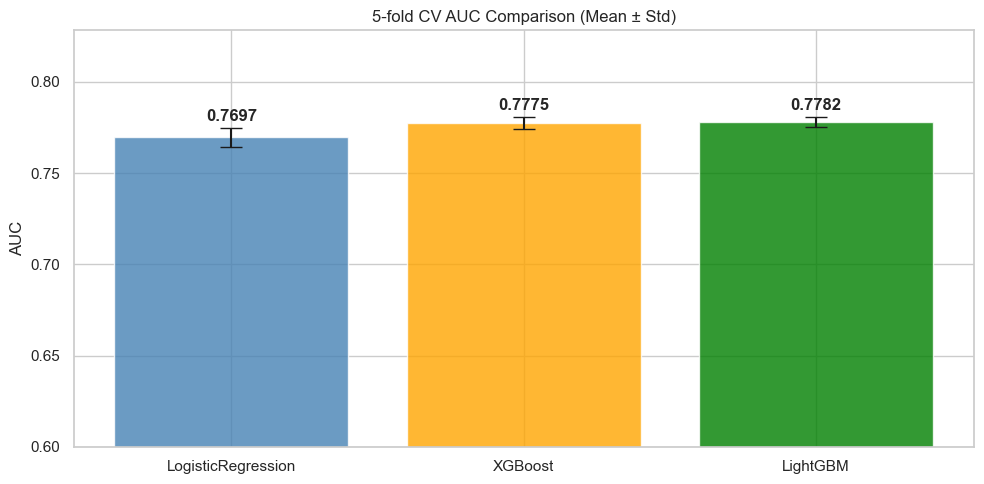

In [57]:
print('=== SO SÁNH 3 MODELS - 5-fold CV AUC ===')
print(f'{"Model":<20} {"Mean AUC":>10} {"Std":>8}')
print('-' * 40)
print(f'{"LogisticRegression":<20} {lr_cv_scores.mean():>10.4f} {lr_cv_scores.std():>8.4f}')
print(f'{"XGBoost":<20} {xgb_cv_scores.mean():>10.4f} {xgb_cv_scores.std():>8.4f}')
print(f'{"LightGBM":<20} {lgb_cv_scores.mean():>10.4f} {lgb_cv_scores.std():>8.4f}')

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
models = ['LogisticRegression', 'XGBoost', 'LightGBM']
means = [lr_cv_scores.mean(), xgb_cv_scores.mean(), lgb_cv_scores.mean()]
stds  = [lr_cv_scores.std(),  xgb_cv_scores.std(),  lgb_cv_scores.std()]
colors = ['steelblue', 'orange', 'green']

bars = ax.bar(models, means, yerr=stds, capsize=8, color=colors, alpha=0.8)
ax.set_ylim(0.6, max(means) + 0.05)
ax.set_ylabel('AUC')
ax.set_title('5-fold CV AUC Comparison (Mean ± Std)')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 0.002,
            f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. TRAIN BEST MODEL & EVALUATE ON TEST SET

In [58]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name, threshold=0.5, scaled=False):
    """Train và evaluate model trên test set."""
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    auc = roc_auc_score(y_te, y_prob)
    
    print(f'\n=== {name} - Test Set ===' )
    print(f'AUC: {auc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['no', 'yes']))
    
    return model, y_prob

# Train tất cả models
logreg.fit(X_train_scaled, y_train)
lr_prob = logreg.predict_proba(X_test_scaled)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)
print('=== LOGISTIC REGRESSION - Test Set ===')
print(f'AUC: {roc_auc_score(y_test, lr_prob):.4f}')
print(classification_report(y_test, lr_pred, target_names=['no', 'yes']))

xgb_model.fit(X_train, y_train)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= 0.5).astype(int)
print('\n=== XGBOOST - Test Set ===')
print(f'AUC: {roc_auc_score(y_test, xgb_prob):.4f}')
print(classification_report(y_test, xgb_pred, target_names=['no', 'yes']))

lgb_model.fit(X_train, y_train)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
lgb_pred = (lgb_prob >= 0.5).astype(int)
print('\n=== LIGHTGBM - Test Set ===')
print(f'AUC: {roc_auc_score(y_test, lgb_prob):.4f}')
print(classification_report(y_test, lgb_pred, target_names=['no', 'yes']))

=== LOGISTIC REGRESSION - Test Set ===
AUC: 0.7760
              precision    recall  f1-score   support

          no       0.94      0.79      0.86      7985
         yes       0.29      0.64      0.40      1058

    accuracy                           0.77      9043
   macro avg       0.61      0.72      0.63      9043
weighted avg       0.87      0.77      0.80      9043


=== XGBOOST - Test Set ===
AUC: 0.7874
              precision    recall  f1-score   support

          no       0.94      0.83      0.88      7985
         yes       0.32      0.62      0.42      1058

    accuracy                           0.80      9043
   macro avg       0.63      0.72      0.65      9043
weighted avg       0.87      0.80      0.83      9043


=== LIGHTGBM - Test Set ===
AUC: 0.7859
              precision    recall  f1-score   support

          no       0.94      0.83      0.88      7985
         yes       0.32      0.62      0.42      1058

    accuracy                           0.80      9

### 7.1 ROC Curve Comparison

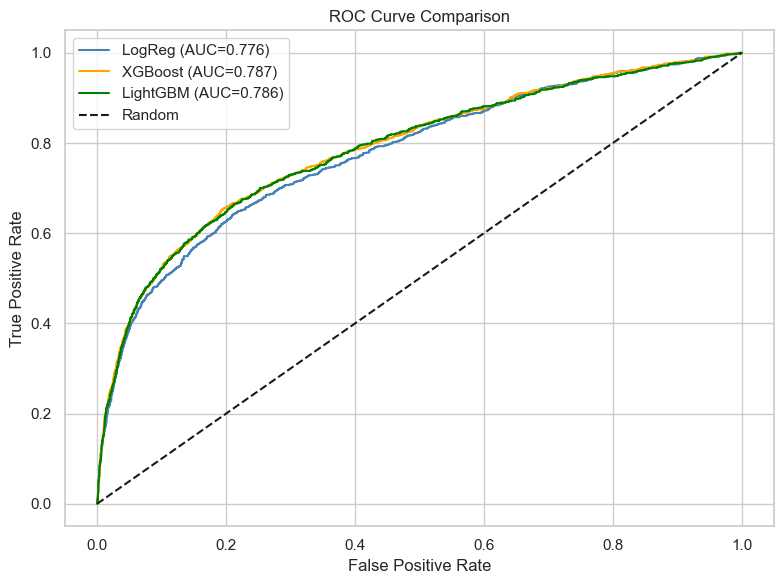

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))

for prob, name, color in [
    (lr_prob, 'LogReg', 'steelblue'),
    (xgb_prob, 'XGBoost', 'orange'),
    (lgb_prob, 'LightGBM', 'green'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

### 7.2 Precision@Top30% (Task 11)

In [60]:
def precision_at_top_pct(y_true, y_prob, pct=0.3):
    """Precision khi lấy top pct% khách có xác suất cao nhất."""
    n_top = int(len(y_prob) * pct)
    top_idx = np.argsort(y_prob)[::-1][:n_top]
    return y_true.iloc[top_idx].mean()

print('=== PRECISION@TOP30% ===')
print(f'LogReg:   {precision_at_top_pct(y_test, lr_prob):.4f}')
print(f'XGBoost:  {precision_at_top_pct(y_test, xgb_prob):.4f}')
print(f'LightGBM: {precision_at_top_pct(y_test, lgb_prob):.4f}')
print(f'\nBaseline (random):  {y_test.mean():.4f}')
print('=> Precision@30% cho biết: Nếu chỉ gọi top 30% khách được model chọn,')
print('   tỉ lệ conversion là bao nhiêu?')

=== PRECISION@TOP30% ===
LogReg:   0.2622
XGBoost:  0.2695
LightGBM: 0.2699

Baseline (random):  0.1170
=> Precision@30% cho biết: Nếu chỉ gọi top 30% khách được model chọn,
   tỉ lệ conversion là bao nhiêu?


---
## 8. SHAP ANALYSIS (Task 6)

Chạy SHAP trên model chính (XGBoost hoặc LightGBM tùy AUC).

In [61]:
# Chọn model tốt nhất theo AUC
best_model_name = 'XGBoost' if roc_auc_score(y_test, xgb_prob) >= roc_auc_score(y_test, lgb_prob) else 'LightGBM'
best_model = xgb_model if best_model_name == 'XGBoost' else lgb_model
print(f'Best model: {best_model_name}')

# SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Nếu LightGBM trả về list (multi-output), lấy class 1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'SHAP values shape: {shap_values.shape}')

Best model: XGBoost
SHAP values shape: (9043, 49)


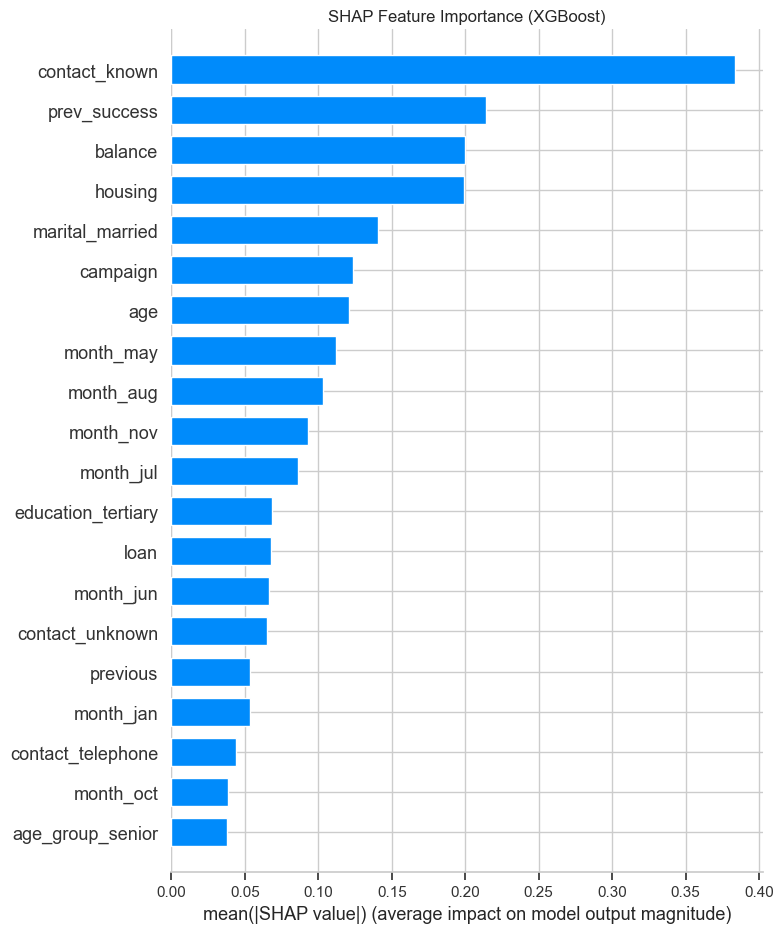

In [62]:
# SHAP Summary Plot - Bar (Feature Importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=20, show=False)
plt.title(f'SHAP Feature Importance ({best_model_name})')
plt.tight_layout()
plt.show()

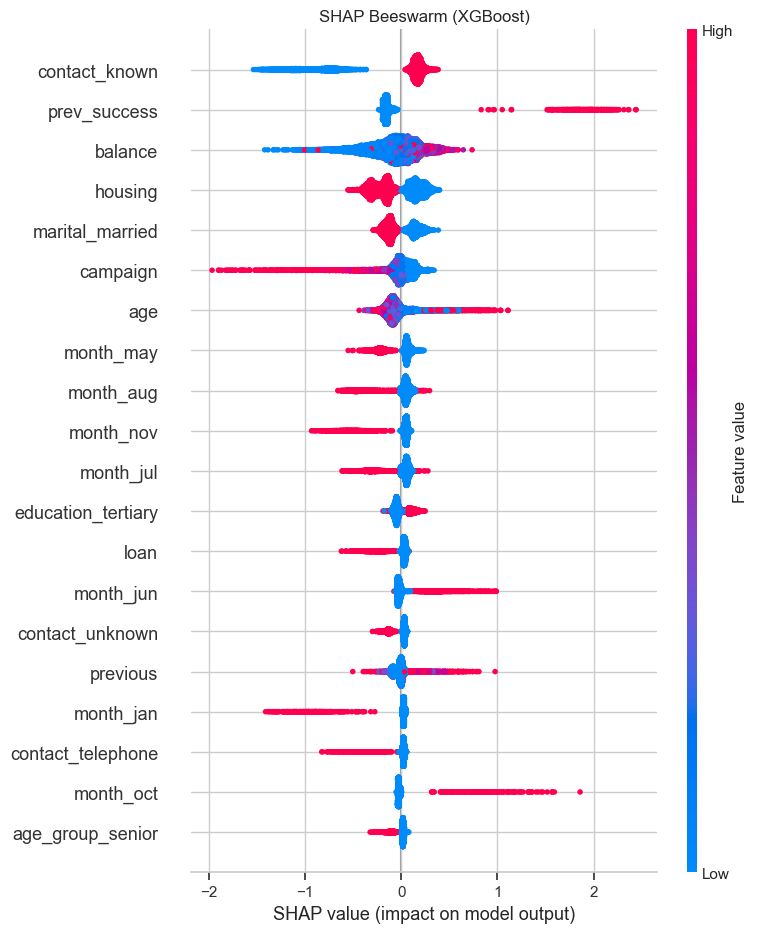

In [63]:
# SHAP Summary Plot - Beeswarm (direction of effect)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title(f'SHAP Beeswarm ({best_model_name})')
plt.tight_layout()
plt.show()

---
## 9. ERROR ANALYSIS (Task 7)

Phân tích các dự đoán sai để tìm pattern model yếu ở đâu.

In [64]:
# Dùng best model
best_prob = xgb_prob if best_model_name == 'XGBoost' else lgb_prob
best_pred = (best_prob >= 0.5).astype(int)

# Tạo dataframe với tất cả thông tin
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

results = X_test_reset.copy()
results['y_true'] = y_test_reset.values
results['y_pred'] = best_pred
results['y_prob'] = best_prob
results['correct'] = (results['y_true'] == results['y_pred']).astype(int)

# Nhóm sai
errors = results[results['correct'] == 0]
# False Negative: thực tế yes nhưng dự đoán no
fn = errors[errors['y_true'] == 1]
# False Positive: thực tế no nhưng dự đoán yes
fp = errors[errors['y_true'] == 0]

print(f'Total errors: {len(errors)} / {len(results)}')
print(f'False Negatives (miss yes): {len(fn)}')
print(f'False Positives (false alarm): {len(fp)}')

# Add original categorical features cho analysis
df_test_orig = df_fe.iloc[X_test.index].reset_index(drop=True)
errors_orig = df_test_orig.loc[errors.index.tolist() if False else errors.index]
# Thực ra cần join lại - sử dụng index gốc
test_indices = X_test.index
df_test_orig_full = df_fe.loc[test_indices].copy()
df_test_orig_full['y_true'] = y_test.values
df_test_orig_full['y_pred'] = best_pred
df_test_orig_full['y_prob'] = best_prob
df_test_orig_full['error_type'] = ''
df_test_orig_full.loc[(df_test_orig_full['y_true']==1) & (df_test_orig_full['y_pred']==0), 'error_type'] = 'FN'
df_test_orig_full.loc[(df_test_orig_full['y_true']==0) & (df_test_orig_full['y_pred']==1), 'error_type'] = 'FP'
df_test_orig_full.loc[df_test_orig_full['y_true']==df_test_orig_full['y_pred'], 'error_type'] = 'correct'

Total errors: 1786 / 9043
False Negatives (miss yes): 398
False Positives (false alarm): 1388


In [65]:
error_df = df_test_orig_full[df_test_orig_full['error_type'].isin(['FN', 'FP'])]

print('\n=== ERROR ANALYSIS BY SEGMENT ===')

# 1. is_new_customer
print('\n--- is_new_customer ---')
print(error_df.groupby(['is_new_customer', 'error_type']).size().unstack(fill_value=0))

# 2. age_group
print('\n--- age_group ---')
print(error_df.groupby(['age_group', 'error_type']).size().unstack(fill_value=0))

# 3. month
print('\n--- month ---')
print(error_df.groupby(['month', 'error_type']).size().unstack(fill_value=0))

# 4. campaign_bucket
print('\n--- campaign_bucket ---')
print(error_df.groupby(['campaign_bucket', 'error_type']).size().unstack(fill_value=0))


=== ERROR ANALYSIS BY SEGMENT ===

--- is_new_customer ---
error_type        FN   FP
is_new_customer          
0                 69  403
1                329  985

--- age_group ---
error_type   FN   FP
age_group           
adult       261  751
retired       7  148
senior       86  178
young        44  311

--- month ---
error_type   FN   FP
month               
apr          31  185
aug          57  188
dec           0   17
feb          18  199
jan          19   33
jul          67  148
jun          42  116
mar           0   36
may         114  214
nov          49  116
oct           0   80
sep           1   56

--- campaign_bucket ---
error_type        FN   FP
campaign_bucket          
1_lan            151  738
2_3_lan          154  489
4_6_lan           70  139
7_plus_lan        23   22


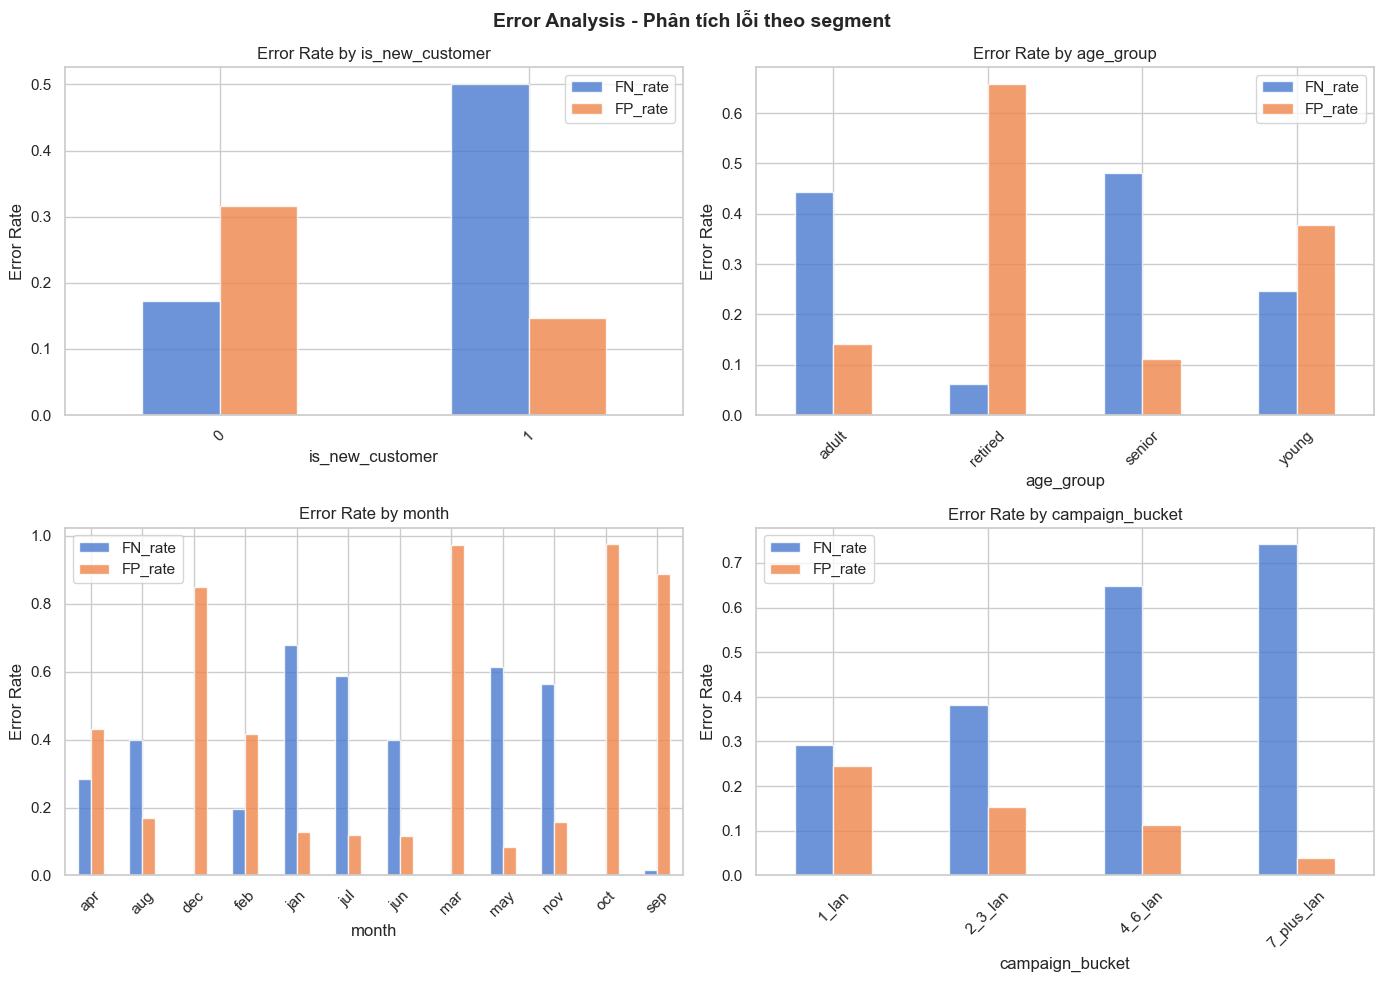

In [66]:
# Visualize error rate theo segment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

segments = ['is_new_customer', 'age_group', 'month', 'campaign_bucket']

for i, seg in enumerate(segments):
    seg_data = df_test_orig_full.groupby(seg).apply(
        lambda g: pd.Series({
            'FN_rate': ((g['error_type'] == 'FN').sum() / max((g['y_true'] == 1).sum(), 1)),
            'FP_rate': ((g['error_type'] == 'FP').sum() / max((g['y_true'] == 0).sum(), 1)),
            'count': len(g)
        })
    )
    seg_data[['FN_rate', 'FP_rate']].plot(kind='bar', ax=axes[i], alpha=0.8)
    axes[i].set_title(f'Error Rate by {seg}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Error Rate')

plt.suptitle('Error Analysis - Phân tích lỗi theo segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. REPRODUCIBILITY CHECK (Task 9)

In [67]:
# Re-train XGBoost với seed cố định và so sánh AUC
xgb_check = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=300,
    learning_rate=0.05,
    random_state=SEED,
    eval_metric='auc',
    verbosity=0
)

xgb_check.fit(X_train, y_train)
check_prob = xgb_check.predict_proba(X_test)[:, 1]
check_auc = roc_auc_score(y_test, check_prob)
orig_auc = roc_auc_score(y_test, xgb_prob)

print('=== REPRODUCIBILITY CHECK ===')
print(f'Original AUC:   {orig_auc:.6f}')
print(f'Re-run AUC:     {check_auc:.6f}')
print(f'Difference:     {abs(orig_auc - check_auc):.8f}')
print(f'Reproducible: {abs(orig_auc - check_auc) < 1e-6}')

=== REPRODUCIBILITY CHECK ===
Original AUC:   0.787426
Re-run AUC:     0.787426
Difference:     0.00000000
Reproducible: True


---
## 11. TỔNG KẾT

### Key Insights từ Feature Engineering

1. **is_new_customer**: Khách mới (pdays=-1) chiếm ~82% dataset nhưng conversion rate thấp hơn nhiều so với khách cũ
2. **prev_success**: Khách cũ đã đồng ý lần trước có conversion ~60% - signal RẤT mạnh
3. **is_negative_balance**: Balance âm (thấu chi) là signal phân biệt rõ - KHÔNG nên clip về 0
4. **campaign_high**: Gọi >3 lần: conversion giảm rõ rệt - nonlinear threshold effect
5. **has_double_loan**: Vay 2 khoản cùng lúc - áp lực tài chính cao, conversion thấp
6. **contact_known**: 29% unknown contact - biết kênh liên lạc là signal tốt

### Model Performance Summary


In [68]:
print('=== FINAL SUMMARY ===')
print()
print('5-fold CV AUC (Train Set):')
print(f'  LogisticRegression: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')
print(f'  XGBoost:           {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}')
print(f'  LightGBM:          {lgb_cv_scores.mean():.4f} ± {lgb_cv_scores.std():.4f}')
print()
print('Test Set AUC:')
print(f'  LogisticRegression: {roc_auc_score(y_test, lr_prob):.4f}')
print(f'  XGBoost:           {roc_auc_score(y_test, xgb_prob):.4f}')
print(f'  LightGBM:          {roc_auc_score(y_test, lgb_prob):.4f}')
print()
print('Precision@Top30%:')
print(f'  LogisticRegression: {precision_at_top_pct(y_test, lr_prob):.4f}')
print(f'  XGBoost:           {precision_at_top_pct(y_test, xgb_prob):.4f}')
print(f'  LightGBM:          {precision_at_top_pct(y_test, lgb_prob):.4f}')
print(f'  Baseline (random):  {y_test.mean():.4f}')
print()
print(f'Best model: {best_model_name}')
print()
print('>>> Business Impact:')
n_over3 = (df['campaign'] > 3).sum()
print(f'  - {n_over3:,} khách ({n_over3/len(df)*100:.1f}%) đang bị gọi >3 lần (lãng phí nguồn lực)')
prev_success_count = (df['poutcome'] == 'success').sum()
double_loan_count = ((df['housing']=='yes') & (df['loan']=='yes')).sum()
double_loan_cr = df[(df['housing']=='yes') & (df['loan']=='yes')]['target'].mean()
print(f'  - {prev_success_count:,} khách đã đồng ý lần trước (conversion ~{df[df["poutcome"]=="success"]["target"].mean():.1%})')
print(f'  - {double_loan_count:,} khách có double loan (conversion chỉ ~{double_loan_cr:.1%})')

=== FINAL SUMMARY ===

5-fold CV AUC (Train Set):
  LogisticRegression: 0.7697 ± 0.0052
  XGBoost:           0.7775 ± 0.0035
  LightGBM:          0.7782 ± 0.0027

Test Set AUC:
  LogisticRegression: 0.7760
  XGBoost:           0.7874
  LightGBM:          0.7859

Precision@Top30%:
  LogisticRegression: 0.2622
  XGBoost:           0.2695
  LightGBM:          0.2699
  Baseline (random):  0.1170

Best model: XGBoost

>>> Business Impact:
  - 9,641 khách (21.3%) đang bị gọi >3 lần (lãng phí nguồn lực)
  - 1,511 khách đã đồng ý lần trước (conversion ~64.7%)
  - 4,367 khách có double loan (conversion chỉ ~6.1%)
